In [1]:
file = "001_RMSE"

In [2]:
column_group = "pyridone"
column_fix = "backbone"
column_target = "beta_av"
column_target_scaled = "beta_av_logit"
column_pred = f"{column_target}_pred"
column_pred_scaled = f"{column_target_scaled}_pred"

# 0. OLS

In [3]:
file_ols = "../../OLS/fit/001_fit"

In [4]:
import polars as pl

df_train_val_rmse_ols = (
    pl.read_parquet(f"{file_ols}_train_val_preds.parquet")
    .with_columns(
        (100 / (1 + (-pl.col(column_target_scaled)).exp())).alias(column_target),
        (100 / (1 + (-pl.col(column_pred_scaled)).exp())).alias(column_pred),
    )
    .group_by("n_features", maintain_order=True)
    .agg(
        (pl.col(column_target) - pl.col(column_pred)).pow(2).mean().sqrt()
        .alias(f"{column_target}_train_val_rmse_ols")
    )
)

In [5]:
df_train_val_rmse_ols

n_features,beta_av_train_val_rmse_ols
i32,f64
51,2.911234
50,2.913593
49,2.913874
48,2.915464
47,2.919272
…,…
9,4.817366
8,5.103922
7,5.491768


In [6]:
df_test_rmse_ols = (
    pl.read_parquet(f"{file_ols}_test_preds.parquet")
    .with_columns(
        (100 / (1 + (-pl.col(column_target_scaled)).exp())).alias(column_target),
        (100 / (1 + (-pl.col(column_pred_scaled)).exp())).alias(column_pred),
    )
    .group_by("n_features", maintain_order=True)
    .agg(
        (pl.col(column_target) - pl.col(column_pred)).pow(2).mean().sqrt()
        .alias(f"{column_target}_test_rmse_ols")
    )
)

In [7]:
df_test_rmse_ols

n_features,beta_av_test_rmse_ols
i32,f64
51,20.887484
50,20.907277
49,20.900522
48,20.898621
47,20.832108
…,…
9,12.507565
8,12.851263
7,12.871252


# 1. PLS

In [8]:
file_pls = "../../PLS/fit/001_fit"

In [9]:
df_train_val_rmse_pls = (
    pl.read_parquet(f"{file_pls}_train_val_preds.parquet")
    .with_columns(
        (100 / (1 + (-pl.col(column_target_scaled)).exp())).alias(column_target),
        (100 / (1 + (-pl.col(column_pred_scaled)).exp())).alias(column_pred),
    )
    .group_by("n_features", maintain_order=True)
    .agg(
        (pl.col(column_target) - pl.col(column_pred)).pow(2).mean().sqrt()
        .alias(f"{column_target}_train_val_rmse_pls")
    )
)

In [10]:
df_train_val_rmse_pls

n_features,beta_av_train_val_rmse_pls
i32,f64
51,5.150155
50,5.126853
49,5.106012
48,5.089423
47,4.994277
…,…
9,4.386749
8,4.610598
7,4.871731


In [11]:
df_test_rmse_pls = (
    pl.read_parquet(f"{file_pls}_test_preds.parquet")
    .with_columns(
        (100 / (1 + (-pl.col(column_target_scaled)).exp())).alias(column_target),
        (100 / (1 + (-pl.col(column_pred_scaled)).exp())).alias(column_pred),
    )
    .group_by("n_features", maintain_order=True)
    .agg(
        (pl.col(column_target) - pl.col(column_pred)).pow(2).mean().sqrt()
        .alias(f"{column_target}_test_rmse_pls")
    )
)

In [12]:
df_test_rmse_pls

n_features,beta_av_test_rmse_pls
i32,f64
51,8.101631
50,7.829475
49,8.063149
48,8.168678
47,8.033116
…,…
9,7.875805
8,8.132144
7,8.092218


# 2. Ridge

In [13]:
file_ridge = "../../Ridge/fit/001_fit"

In [14]:
df_train_val_rmse_ridge = (
    pl.read_parquet(f"{file_ridge}_train_val_preds.parquet")
    .with_columns(
        (100 / (1 + (-pl.col(column_target_scaled)).exp())).alias(column_target),
        (100 / (1 + (-pl.col(column_pred_scaled)).exp())).alias(column_pred),
    )
    .group_by("n_features", maintain_order=True)
    .agg(
        (pl.col(column_target) - pl.col(column_pred)).pow(2).mean().sqrt()
        .alias(f"{column_target}_train_val_rmse_ridge")
    )
)

In [15]:
df_train_val_rmse_ridge

n_features,beta_av_train_val_rmse_ridge
i32,f64
51,4.646271
50,4.612375
49,4.484954
48,4.466735
47,4.425488
…,…
9,4.299564
8,4.503741
7,4.752061


In [16]:
df_test_rmse_ridge = (
    pl.read_parquet(f"{file_ridge}_test_preds.parquet")
    .with_columns(
        (100 / (1 + (-pl.col(column_target_scaled)).exp())).alias(column_target),
        (100 / (1 + (-pl.col(column_pred_scaled)).exp())).alias(column_pred),
    )
    .group_by("n_features", maintain_order=True)
    .agg(
        (pl.col(column_target) - pl.col(column_pred)).pow(2).mean().sqrt()
        .alias(f"{column_target}_test_rmse_ridge")
    )
)

In [17]:
df_test_rmse_ridge

n_features,beta_av_test_rmse_ridge
i32,f64
51,7.174818
50,7.181588
49,7.1544
48,7.145989
47,7.160939
…,…
9,7.2698
8,7.354834
7,7.986625


# 3. Lasso

In [18]:
file_lasso = "../../Lasso/fit/001_fit"

In [19]:
import numpy as np

df_train_val_rmse_lasso = (
    pl.DataFrame({f"{column_group}_test": np.arange(13)})
    .join(pl.DataFrame({"n_features": np.arange(51, 4, -1)}), how="cross")
    .join(pl.DataFrame({column_group: np.arange(13)}), how="cross")
    .join(pl.DataFrame({column_fix: [0, 1, 2, 3, 4, 5, 19, 20]}), how="cross")
    .filter(pl.col(f"{column_group}_test") != pl.col(column_group))
    .join(
        pl.read_parquet(f"{file_lasso}_train_val_preds.parquet"),
        on=[f"{column_group}_test", "n_features", column_group, column_fix],
        how="left",
        maintain_order="left"
    )
    .with_columns(
        (100 / (1 + (-pl.col(column_target_scaled)).exp())).alias(column_target),
        (100 / (1 + (-pl.col(column_pred_scaled)).exp())).alias(column_pred),
    )
    .with_columns(
        pl.col([column_target, column_pred])
        .forward_fill()
        .over([f"{column_group}_test", column_group, column_fix])
    )
    .group_by("n_features", maintain_order=True)
    .agg(
        (pl.col(column_target) - pl.col(column_pred)).pow(2).mean().sqrt()
        .alias(f"{column_target}_train_val_rmse_lasso")
    )
)

In [20]:
df_train_val_rmse_lasso

n_features,beta_av_train_val_rmse_lasso
i64,f64
51,4.421704
50,4.421704
49,4.421704
48,4.421704
47,4.421704
…,…
9,4.494824
8,4.552691
7,4.742785


In [21]:
df_test_rmse_lasso = (
    pl.DataFrame({f"{column_group}_test": np.arange(13)})
    .join(pl.DataFrame({"n_features": np.arange(51, 4, -1)}), how="cross")
    .join(pl.DataFrame({column_fix: [0, 1, 2, 3, 4, 5, 19, 20]}), how="cross")
    .join(
        pl.read_parquet(f"{file_lasso}_test_preds.parquet"),
        on=[f"{column_group}_test", "n_features", column_fix],
        how="left",
        maintain_order="left"
    )
    .with_columns(
        (100 / (1 + (-pl.col(column_target_scaled)).exp())).alias(column_target),
        (100 / (1 + (-pl.col(column_pred_scaled)).exp())).alias(column_pred),
    )
    .with_columns(
        pl.col([column_target, column_pred])
        .forward_fill()
        .over([f"{column_group}_test", column_fix])
    )
    .group_by("n_features", maintain_order=True)
    .agg(
        (pl.col(column_target) - pl.col(column_pred)).pow(2).mean().sqrt()
        .alias(f"{column_target}_test_rmse_lasso")
    )
)

In [22]:
df_test_rmse_lasso

n_features,beta_av_test_rmse_lasso
i64,f64
51,6.902219
50,6.902219
49,6.902219
48,6.902219
47,6.902219
…,…
9,6.884937
8,6.771396
7,7.026248


# 4. Combined plot

In [23]:
df_rmse = pl.concat(
    [
        df_train_val_rmse_ols,
        df_test_rmse_ols,
        df_train_val_rmse_pls,
        df_test_rmse_pls,
        df_train_val_rmse_ridge,
        df_test_rmse_ridge,
        df_train_val_rmse_lasso,
        df_test_rmse_lasso,
    ],
    how="align"
)

In [24]:
df_rmse = df_rmse.sort("n_features")

In [25]:
df_rmse

n_features,beta_av_train_val_rmse_ols,beta_av_test_rmse_ols,beta_av_train_val_rmse_pls,beta_av_test_rmse_pls,beta_av_train_val_rmse_ridge,beta_av_test_rmse_ridge,beta_av_train_val_rmse_lasso,beta_av_test_rmse_lasso
i64,f64,f64,f64,f64,f64,f64,f64,f64
5,7.204432,13.698775,5.551625,9.464304,5.430574,8.385205,5.634711,8.0088
6,6.077398,13.791842,5.108154,8.691552,4.948247,8.077805,5.267487,7.492126
7,5.491768,12.871252,4.871731,8.092218,4.752061,7.986625,4.742785,7.026248
8,5.103922,12.851263,4.610598,8.132144,4.503741,7.354834,4.552691,6.771396
9,4.817366,12.507565,4.386749,7.875805,4.299564,7.2698,4.494824,6.884937
…,…,…,…,…,…,…,…,…
47,2.919272,20.832108,4.994277,8.033116,4.425488,7.160939,4.421704,6.902219
48,2.915464,20.898621,5.089423,8.168678,4.466735,7.145989,4.421704,6.902219
49,2.913874,20.900522,5.106012,8.063149,4.484954,7.1544,4.421704,6.902219


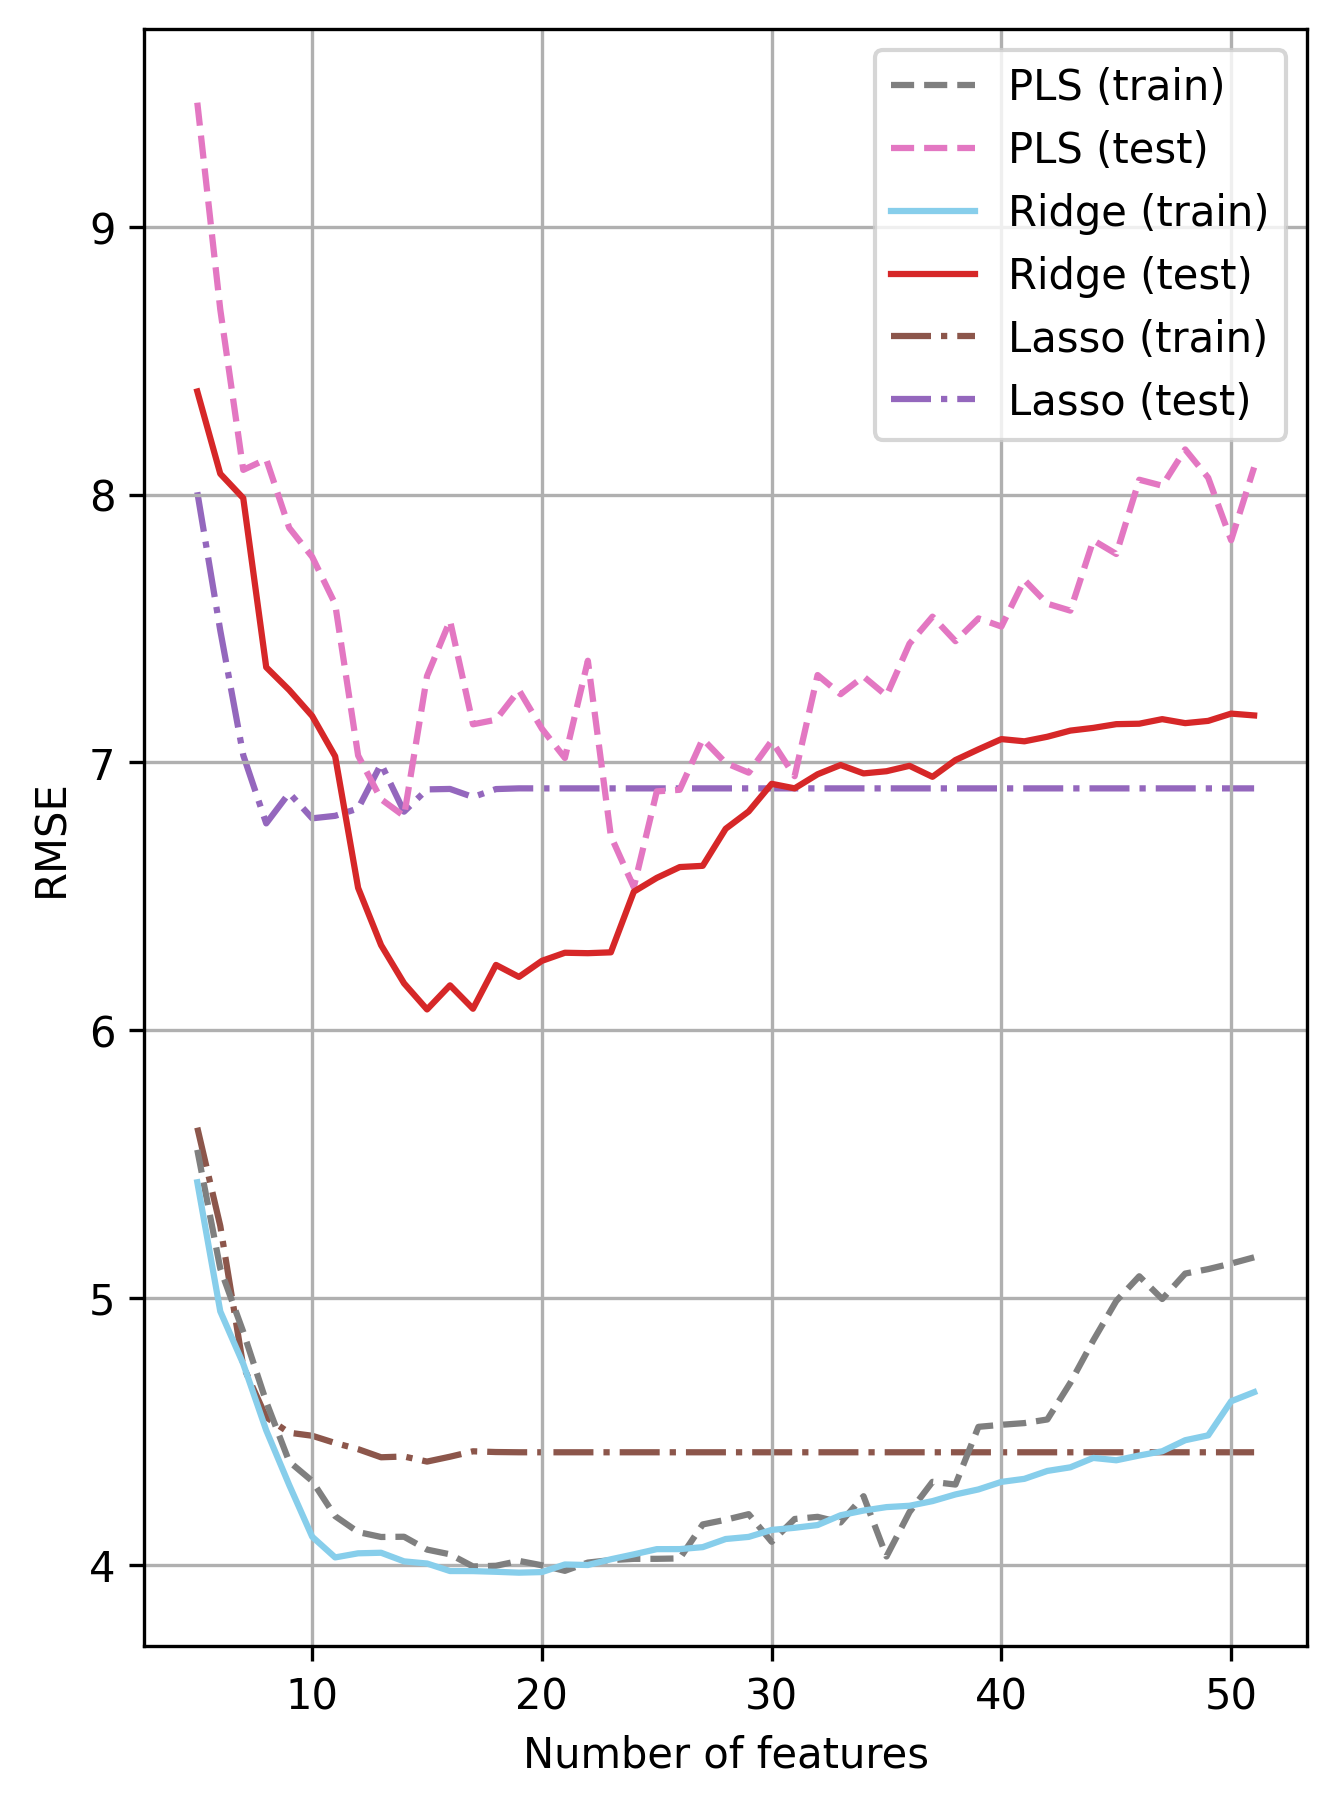

In [26]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 7), dpi=300)

ax.plot(
    df_rmse["n_features"],
    df_rmse[f"{column_target}_train_val_rmse_pls"],
    c="tab:gray",
    label="PLS (train)",
    zorder=2,
    ls="--"
)
ax.plot(
    df_rmse["n_features"],
    df_rmse[f"{column_target}_test_rmse_pls"],
    c="tab:pink",
    label="PLS (test)",
    zorder=3,
    ls="--"
)
ax.plot(
    df_rmse["n_features"],
    df_rmse[f"{column_target}_train_val_rmse_ridge"],
    c="skyblue",
    label="Ridge (train)",
    zorder=4
)
ax.plot(
    df_rmse["n_features"],
    df_rmse[f"{column_target}_test_rmse_ridge"],
    c="tab:red",
    label="Ridge (test)",
    zorder=5
)
ax.plot(
    df_rmse["n_features"],
    df_rmse[f"{column_target}_train_val_rmse_lasso"],
    c="tab:brown",
    label="Lasso (train)",
    zorder=0,
    ls="-."
)
ax.plot(
    df_rmse["n_features"],
    df_rmse[f"{column_target}_test_rmse_lasso"],
    c="tab:purple",
    label="Lasso (test)",
    zorder=1,
    ls="-."
)

ax.set_xlabel("Number of features")
ax.set_ylabel("RMSE")

ax.grid()
ax.legend()

plt.savefig(
    f"{file}_plot_all.png",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.show()

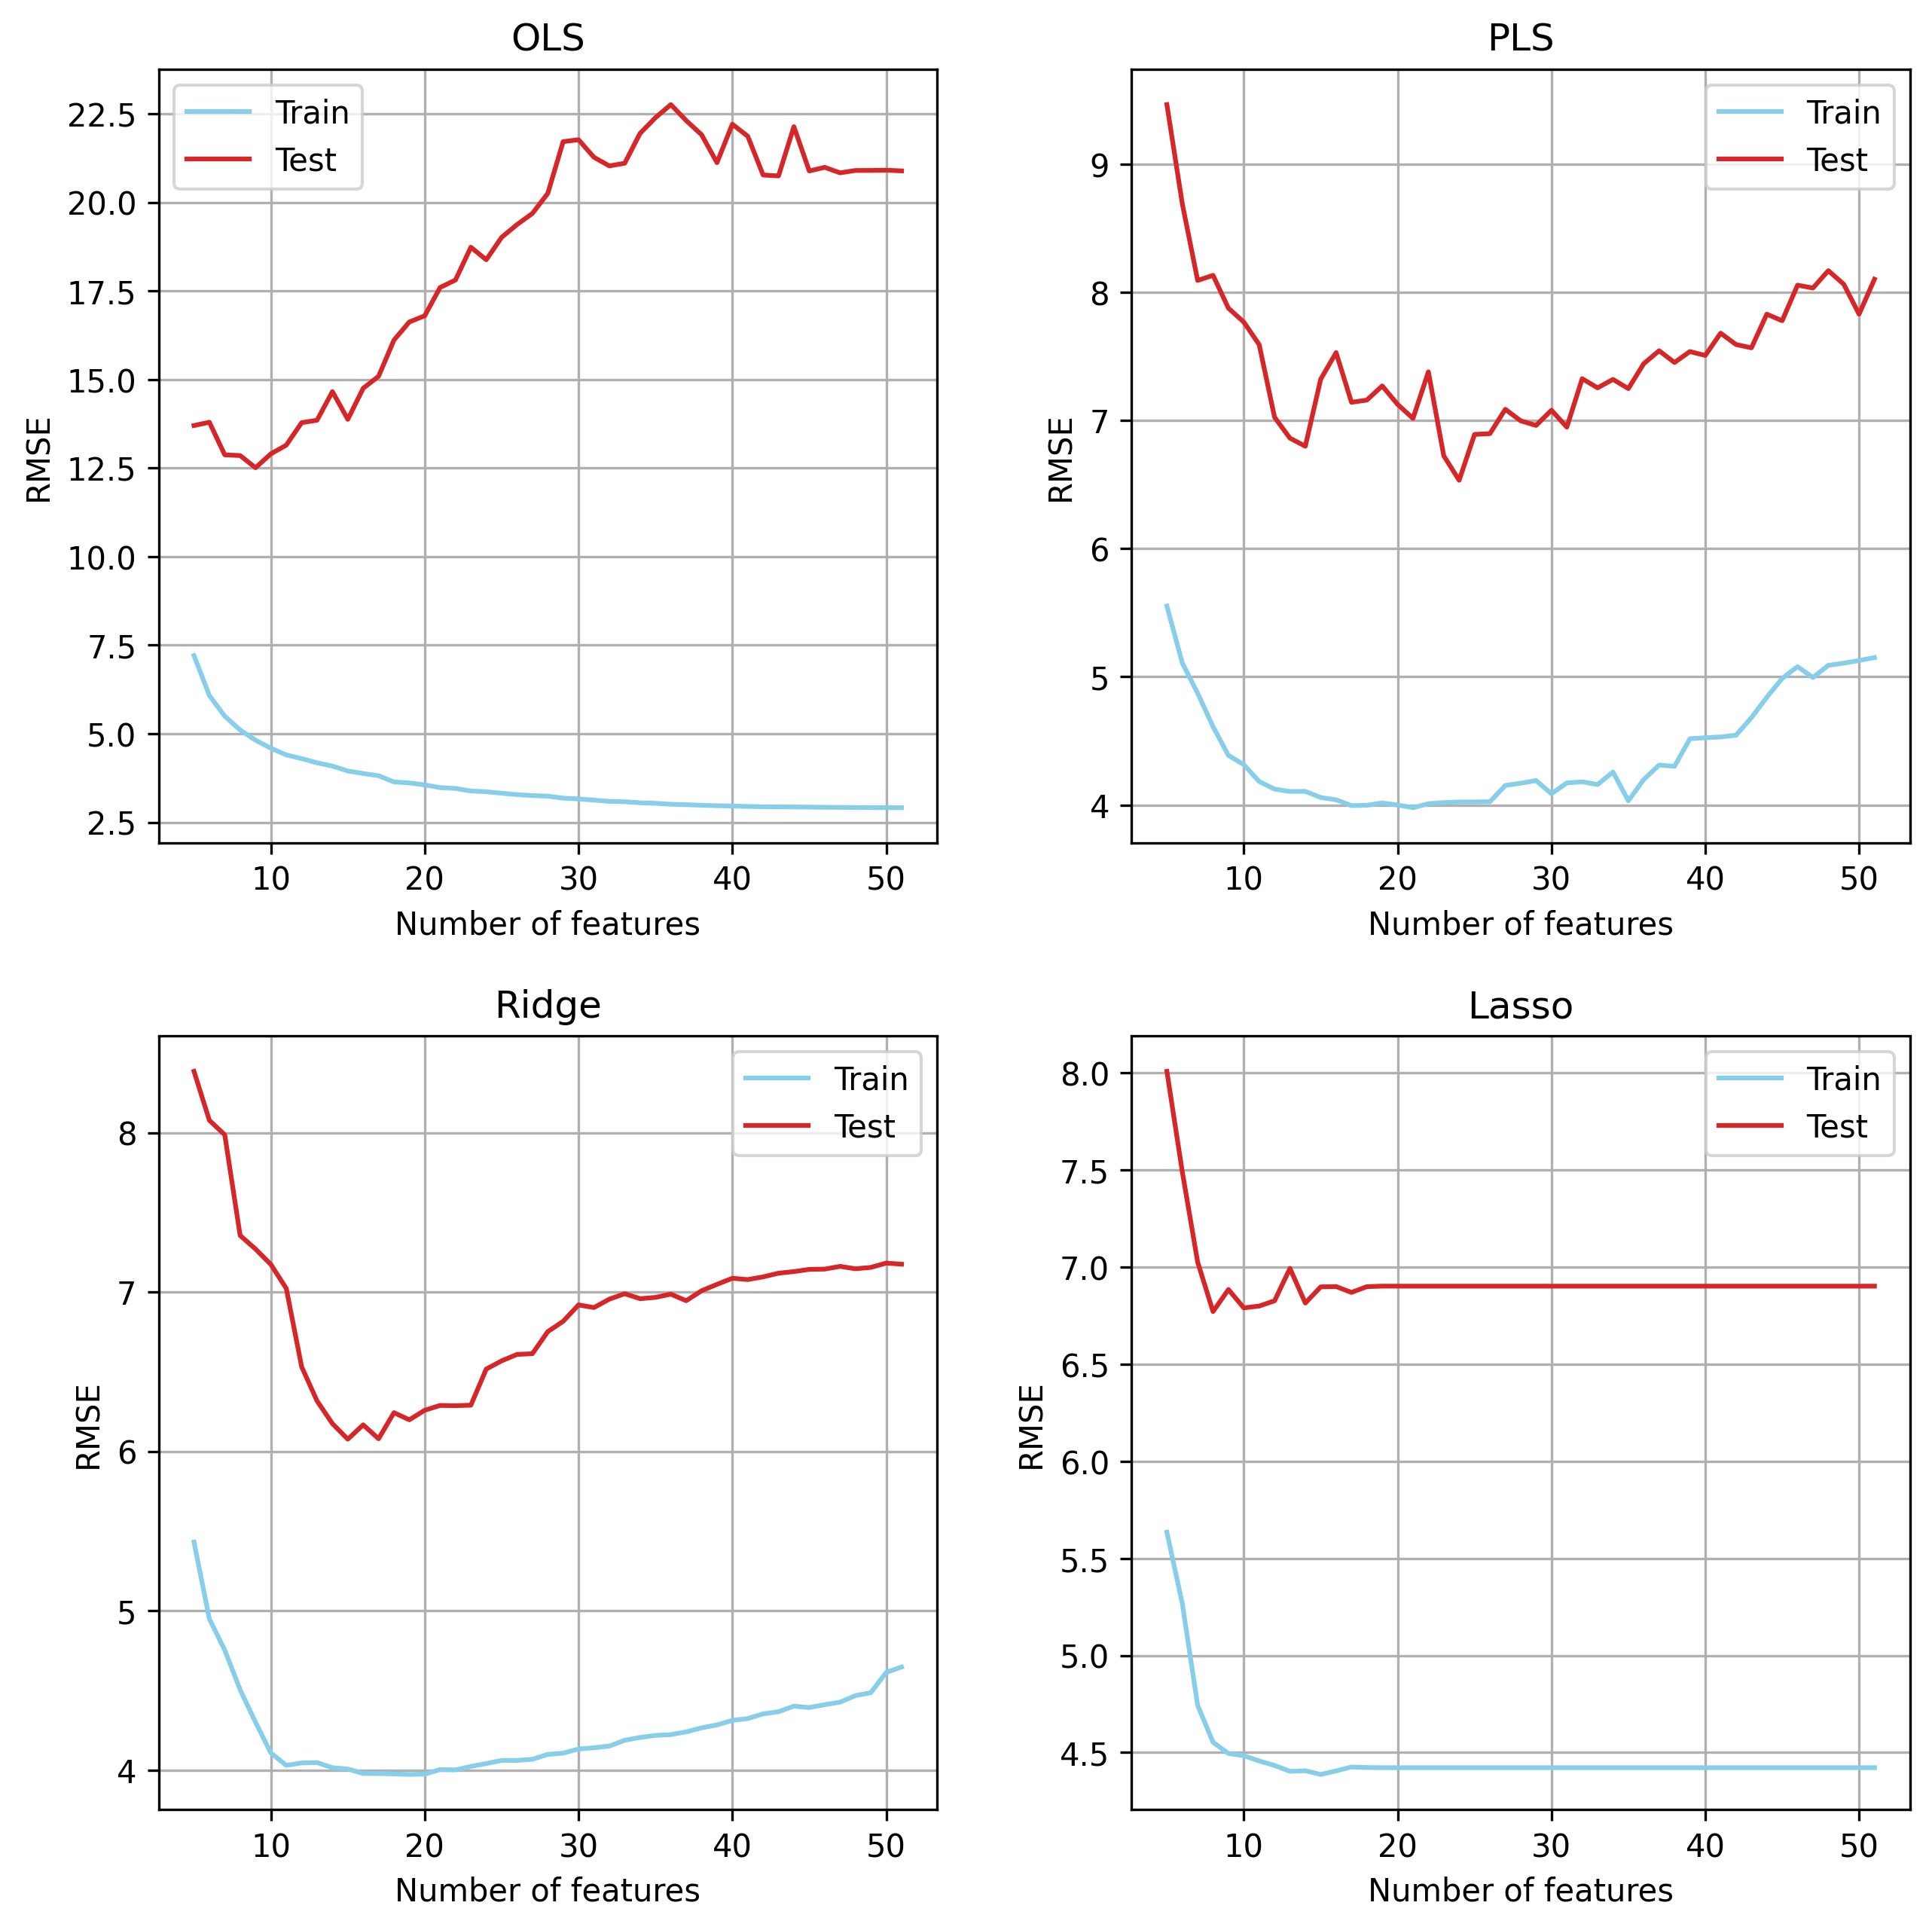

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10), dpi=300)
fig.subplots_adjust(wspace=0.25, hspace=0.25)

for i, model in enumerate(["OLS", "PLS", "Ridge", "Lasso"]):
    div, mod = divmod(i, 2)
    
    axes[div, mod].plot(
        df_rmse["n_features"],
        df_rmse[f"{column_target}_train_val_rmse_{model.lower()}"],
        c="skyblue",
        label="Train"
    )
    axes[div, mod].plot(
        df_rmse["n_features"],
        df_rmse[f"{column_target}_test_rmse_{model.lower()}"],
        c="tab:red",
        label="Test"
    )
    
    axes[div, mod].set_title(model)
    axes[div, mod].set_xlabel("Number of features")
    axes[div, mod].set_ylabel("RMSE")
    
    axes[div, mod].grid()
    axes[div, mod].legend()

plt.savefig(
    f"{file}_plot_each.png",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.show()